# Racetrack Resonator -- Meep Baseline, Coupling-Length Search, and Design Selection

This is the fifth "LEGO block" in the toolkit: a single-bus (all-pass) **racetrack**
resonator -- a ring whose coupling section is a straight waveguide run rather than a
single point of closest approach. Like the earlier notebooks, this one is an
educational/validation record, not just a script -- work through it step by step,
and stop at the marked checkpoints.

## Why a racetrack, and not a plain ring

Coupling strength between a bus and a ring can be controlled two ways: shrinking the
bus-ring **gap**, or lengthening the **straight coupling section** (a "racetrack").
This notebook uses the racetrack approach: the gap stays fixed at a comfortable,
easily-resolved **200nm**, and `coupling_length_um` -- the length of the straight
segment where the racetrack runs parallel to the bus -- is the coupling-strength
knob instead. Longer interaction length buys stronger coupling exactly like a
smaller gap would, without ever needing sub-wavelength resolution to resolve the
gap itself, and without forcing ring size and simulation-domain size to trade off
against each other.

## What a racetrack resonator is

A **racetrack** is two half-circles (radius `radius_um`, to the waveguide centerline)
joined by two straight segments (length `coupling_length_um`) -- a "stadium" shape. A
**bus waveguide** runs straight past the racetrack's *top* straight segment, separated
by a small, fixed gap; its evanescent field (the exponentially-decaying tail that
extends slightly beyond a guided mode's core) overlaps the racetrack across that gap --
**evanescent coupling**: a small, controllable fraction of the bus power leaks into the
racetrack on every pass, and an equal fraction leaks back out.

Once light is coupled into the racetrack, it circulates around the loop. The
racetrack's optical path length is now
$$L = 2\pi R + 2 L_c$$
(both straight segments contribute, even though only the one nearest the bus actually
couples to anything) -- one extra term over a plain ring's $L=2\pi R$. For most
wavelengths, light that has gone around once arrives back at the coupling point out of
step with light still arriving fresh from the bus, and the two interfere
**destructively**. But at specific wavelengths, the round-trip phase is a whole number
of cycles, the circulating light interferes **constructively** with itself, and builds
up to a much larger intensity inside the racetrack -- a **resonance**:
$$m\,\lambda_{res} = n_{eff}\, L \qquad (m = 1, 2, 3, \dots)$$
At resonance, the built-up circulating field re-couples back out to the bus mostly out
of phase with the light that never coupled in at all -- the two partially cancel,
producing a transmission dip whose depth depends on how closely the coupled-out power
matches the racetrack's own intrinsic loss (**critical coupling**, Section 9).

**Do not use "Run All."** Work through the notebook step by step, and stop at the two
marked checkpoints to actually look at the plots before continuing.


## 2. User parameters

Same units and material convention as `01_waveguide_baseline.ipynb`: lengths in
micrometers, silicon core / silicon dioxide cladding.

In [1]:
import inspect

import numpy as np
import matplotlib.pyplot as plt
import gdsfactory as gf

from pic_toolkit.meep_sim import racetrack
from pic_toolkit import checks, viz, sparams, design_points, sweep, style

style.apply_style()  # shared color palette + plot style for every notebook in this toolkit
%matplotlib inline

# ============================================================
# USER PARAMETERS
# ============================================================
params = dict(racetrack.DEFAULT_PARAMS)  # everything below reads from/derives off this dict
params


{'radius_um': 5.0,
 'gap_um': 0.2,
 'coupling_length_um': 3.0,
 'wg_width_um': 0.5,
 'wg_height_um': 0.22,
 'core_index': 2.7,
 'clad_index': 1.44,
 'ring_conductivity': 0.001,
 'wl_min_um': 1.3,
 'wl_max_um': 1.4,
 'n_freq': 301,
 'resolution': 25,
 'dpml_um': 1.0,
 'margin_um': 0.5,
 'dft_decay_tol': 0.001,
 'min_sim_time': 7000,
 'max_sim_time': 25000}

What each parameter means physically (see `docs/simulation_settings_record.md`
for the studies behind the non-obvious choices):

- **`radius_um`** -- half-circle (centerline) radius, kept at a realistic 5um.
  **Not swept in this notebook** -- `coupling_length_um` is the coupling-strength
  knob here, not the radius.
- **`gap_um`** -- bus-racetrack separation, **fixed at 200nm**, comfortably
  resolved by the grid. Coupling strength is instead controlled by
  `coupling_length_um` (Section 1 explains why).
- **`coupling_length_um`** -- length of the straight racetrack segment running
  parallel to the bus, and the primary knob varied in this notebook. Set here to
  ~3um as the Sections 3-9 baseline; Section 10 sweeps around it to find the best
  coupling length.
- **`ring_conductivity`** -- a small electric conductivity (Meep `D_conductivity`)
  applied only to the racetrack's core material (the bus stays lossless), standing
  in for a real fabricated waveguide's propagation loss. Without some intrinsic
  loss channel there is nothing for the coupling to be "critical" against.
- **`wg_width_um`** -- waveguide width, same convention as every other component,
  used for both the bus and the racetrack.
- **`wg_height_um`** -- vertical thickness of the real 3D device this 2D model
  approximates. Not used by the simulation -- carried as metadata only.
- **`wl_min_um` / `wl_max_um` / `n_freq`** -- wavelength sweep range (O-band,
  1300-1400nm) and resolution. `n_freq=301`: this resonator's dips are only a
  few nm wide, so a denser grid than most components is needed to resolve them.
- **`resolution`** -- pixels/um, 25 -- still resolves the 200nm gap with 5 grid
  points; the main cost driver here is `min_sim_time` below, not spatial
  resolution.
- **`dft_decay_tol` / `min_sim_time` / `max_sim_time`** -- FDTD convergence
  controls for `mp.stop_when_dft_decayed()`. `min_sim_time` is an explicit floor:
  a longer coupling length couples into a higher-loaded-Q resonance whose
  ring-down decays slowly, and the default "has the change between checks
  plateaued" criterion can register as converged before the field has actually
  settled.


## 3. Build geometry

The bus and ring are built as TWO SEPARATE gdsfactory `Component`s (not merged into
one) -- the ring needs a lossy `ring_core` material (`D_conductivity=
ring_conductivity`) while the bus stays lossless, and `gds_import.py`'s
`gds_component_to_prisms()` only accepts one `material=` per call. The ring itself is
a single CLOSED gdsfactory `Path` (straight -> 180-degree arc -> straight -> 180-degree
arc, back to the start), extruded to `wg_width_um` -- the extruded closed loop is
already hollow (KLayout represents it as one self-touching "keyhole" polygon rather
than a polygon-with-holes structure, but the interior is confirmed correctly
cladding-index when rendered -- `gds_import.py` needed no changes to handle this).

(The earlier native-Meep-only construction this notebook used before the GDSFactory
migration is no longer shown here; `racetrack.py`'s `build_geometry()` function and
`use_native_geometry` flag remain in the module as reference code for anyone comparing
the two approaches directly in a REPL.)


In [2]:
print(inspect.getsource(racetrack._ring_gf_component))

def _ring_gf_component(params: dict):
    """The racetrack ring as ONE closed-loop gdsfactory Path (straight ->
    180-degree arc -> straight -> 180-degree arc, back to the start),
    extruded to wg_width_um -- a single annular Component, unlike
    build_geometry's native outer+inner stadium-carving pair. KLayout
    represents the resulting annulus as one self-touching "keyhole" simple
    polygon (`poly.holes()` reports 0), NOT a polygon-with-holes structure --
    confirmed empirically (direct epsilon sampling through
    gds_import.get_permittivity_map) that the interior is correctly hollow
    regardless, so gds_import.gds_component_to_prisms needs no changes.

    IMPORTANT: `gf.path.straight(length=0)` is NOT a geometric no-op -- at
    coupling_length_um=0 it corrupts the closed loop into a self-intersecting
    shape roughly 3.7x too wide (confirmed empirically: bbox width ~38.8um
    instead of the correct ~10.5um at radius_um=5). The `Lc > 0` branch below
    must omit th

In [3]:
print(inspect.getsource(racetrack.build_gf_component))
print(inspect.getsource(racetrack.build_geometry_from_gds))

def build_gf_component(params: dict) -> tuple:
    """Returns (bus, ring): two SEPARATE gdsfactory Components in the shared
    _compute_domain() coordinate frame. Kept separate (not merged into one
    Component) because they need DIFFERENT Meep materials once converted --
    plain `core` for the bus vs. lossy `ring_core` (D_conductivity=
    ring_conductivity) for the ring -- see build_geometry_from_gds."""
    return _bus_gf_component(params), _ring_gf_component(params)

def build_geometry_from_gds(params: dict) -> list:
    """Meep geometry sourced from build_gf_component via gds_import -- the
    default simulation path (see use_native_geometry flags below). Simpler
    than native build_geometry: the ring's closed-loop Path extrusion is
    already hollow, so no separate outer-stadium/inner-stadium carving pair
    is needed."""
    core = mp.Medium(index=params["core_index"])
    ring_core = mp.Medium(index=params["core_index"], D_conductivity=params["ring_conductivity"])
    b

**Why the ring Component has no ports**: it's a CLOSED loop -- its start and end point
are the same coincident point (the seam where the path closes). There is no physically
meaningful port on a closed ring, so `_ring_gf_component()` deliberately does not call
`add_ports()`. Only the bus Component has ports (`o1`/`o2`).

bus bbox: (-10.25,5.1;10.25,5.6)  ports: {'o1': ((-10.25, 5.3500000000000005), 180.0), 'o2': ((10.25, 5.3500000000000005), 0.0)}
ring bbox: (-6.748,-5.6;6.748,4.9)  (no ports -- closed loop, see markdown above)


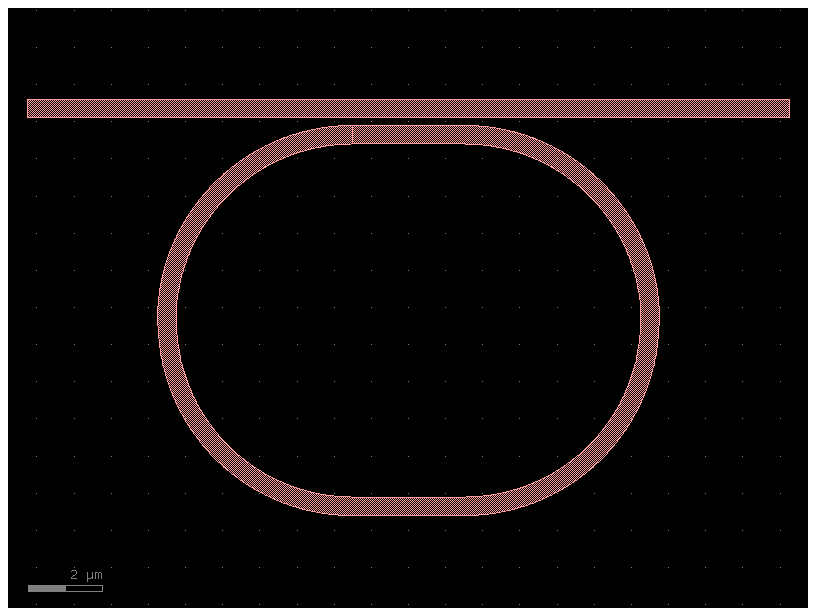

In [4]:
# Build both parts of the device as gdsfactory Components (kept separate --
# see the markdown above for why), then print their bounding boxes/ports so we
# can sanity-check sizes before rendering or simulating anything.
bus_gf, ring_gf = racetrack.build_gf_component(params)
print("bus bbox:", bus_gf.dbbox(), " ports:", {p.name: (p.dcenter, p.orientation) for p in bus_gf.ports})
print("ring bbox:", ring_gf.dbbox(), " (no ports -- closed loop, see markdown above)")

# Combine both Components into one throwaway Component purely for this plot --
# this is what the actual fabricated layout looks like (bus straight + racetrack
# ring, separated by the coupling gap).
combined = gf.Component()
combined.add_ref(bus_gf)
combined.add_ref(ring_gf)
fig = combined.plot()
plt.show()


## 4. Permittivity map

Built WITHOUT running any FDTD timestepping, exactly as in every other component --
the usual baseline-vs-degenerate-ring comparison, shown using the GDSFactory-derived
geometry (Section 3), since that's what `coupling_length_um=0` will actually exercise
going forward.


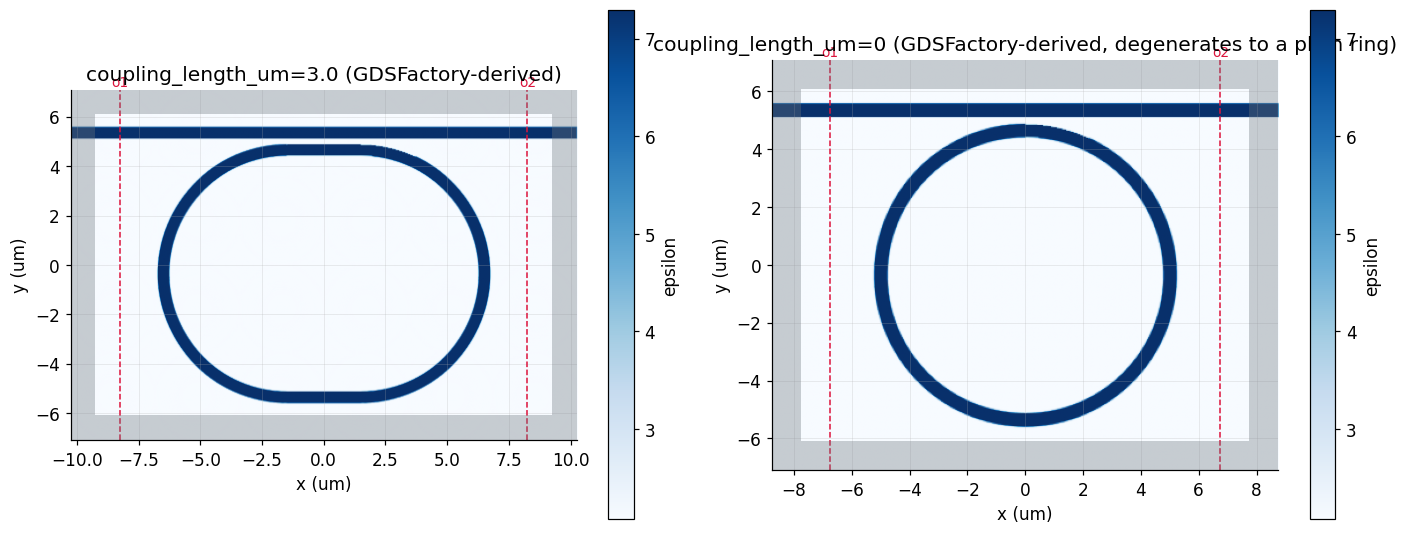

In [5]:
# Two side-by-side permittivity maps, computed WITHOUT running any FDTD
# timestepping (cheap): the actual device (left) and the coupling_length_um=0
# degenerate case (right), which collapses the racetrack into a plain circular
# ring -- a useful visual sanity check that the stadium shape is built correctly.
def _ports_for(p):
    dom = racetrack._compute_domain(p)
    return [
        (-dom["port_offset"], dom["bus_y"], "o1", "v"),
        (dom["port_offset"], dom["bus_y"], "o2", "v"),
    ]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

perm_map = racetrack.get_permittivity_map(params)  # use_native_geometry=False by default -- GDSFactory-derived
viz.plot_permittivity(perm_map.eps, perm_map.extent_um, ax=axes[0],
                       ports=_ports_for(params), pml_um=params["dpml_um"])
axes[0].set_title(f"coupling_length_um={params['coupling_length_um']} (GDSFactory-derived)")

params0 = {**params, "coupling_length_um": 0.0}
perm_map0 = racetrack.get_permittivity_map(params0)
viz.plot_permittivity(perm_map0.eps, perm_map0.extent_um, ax=axes[1],
                       ports=_ports_for(params0), pml_um=params0["dpml_um"])
axes[1].set_title("coupling_length_um=0 (GDSFactory-derived, degenerates to a plain ring)")

fig.tight_layout()
plt.show()


> **STOP -- INSPECT THE PERMITTIVITY MAP BEFORE RUNNING FDTD.**
>
> Check, before paying for an expensive simulation:
> - **Racetrack shape**: a stadium (two half-circles + two straight runs) in the left
>   panel, collapsing to a plain circle in the right panel.
> - **Bus-racetrack gap**: is there a clear, uniform 200nm gap between the bus and the
>   nearest point of the racetrack's top straight segment?
> - **Waveguide width**: are the bus and racetrack cross-sections both `wg_width_um`
>   wide?
> - **Racetrack position**: is it centered horizontally under the bus?
> - **Domain size / PML placement**: visible clearance between the structure and the
>   domain edges, no overlap with PML.
> - **No unintended overlaps**: bus and racetrack should not touch or intersect.
>
> If anything looks wrong, fix `params` above and re-run from Section 3.


## 5. Baseline FDTD simulation

Same rigorous two-port philosophy as every other component: `simulate_baseline()`
excites from **each port independently** and measures the full 2x2 complex S-matrix
from genuinely independent data. It also runs one extra **reference simulation**
first, with the racetrack removed (bus only), to measure the true incident mode
amplitude -- the same normalization approach the earlier ring prototype needed, and
for the same reason: a resonant structure can leave energy circulating long after the
source pulse itself has finished, contaminating self-normalization.

**Geometry source**: `simulate_baseline()` uses the GDSFactory-derived geometry
(Section 3) by default (`use_native_geometry=False`) -- including the bus-only
reference run, which sources its bus from the SAME `_bus_gf_component()` the with-ring
run uses, so both runs' bus discretization matches exactly (see `_reference_incident`'s
docstring for why a mismatch here would matter).

The source-bandwidth-margin fix the earlier ring prototype needed (a Gaussian
source's spectral power falling off toward the edges of its own frequency window) is
reused here verbatim -- see `racetrack._SOURCE_BANDWIDTH_MARGIN`.


In [6]:
# Full two-port characterization at the Section-2 baseline coupling_length_um --
# this runs the reference (bus-only) simulation plus both excitation directions
# under the hood (see the markdown above), so the full 2x2 S-matrix below is
# built from genuinely independent measurements, not assumed symmetry.
result = racetrack.simulate_baseline(params)
print(f"{len(result.wavelengths_um)} wavelength points, "
      f"{result.wavelengths_um.min():.4f}-{result.wavelengths_um.max():.4f} um")


301 wavelength points, 1.3017-1.4020 um


## 6. S-parameters

The complete complex 2x2 S-matrix, exactly as in every other component -- not only
S21.

**Magnitude only, no phase plot.** This band (1.30-1.40um, 301 points) contains about 5 resonances (FSR $\approx \lambda^2/(n_{eff}L) \approx 20$nm), each only a few nm wide. Near every resonance the phase genuinely sweeps by $\sim 2\pi$ -- real physics, and `np.unwrap` handles it correctly -- but that sweep spans only a handful of grid points here, so the correctly-unwrapped curve still looks like a staircase of jumps rather than a smooth ramp. That is a sampling-density limit of this baseline grid, not a bug, and resolving it would need many more wavelength points than this view is meant for. The magnitude plot below already shows every resonance clearly.


In [7]:
# Quick numeric sanity check before plotting: every |S|^2 should sit in [0, 1]
# (a passive device can't amplify) -- a full plot follows below.
for key in ["11", "12", "21", "22"]:
    s = result.s_matrix[key]
    print(f"S{key}: |S|^2 range [{np.min(np.abs(s)**2):.4f}, {np.max(np.abs(s)**2):.4f}]")


S11: |S|^2 range [0.0000, 0.0385]
S12: |S|^2 range [0.2996, 0.9992]
S21: |S|^2 range [0.2999, 0.9993]
S22: |S|^2 range [0.0001, 0.0380]


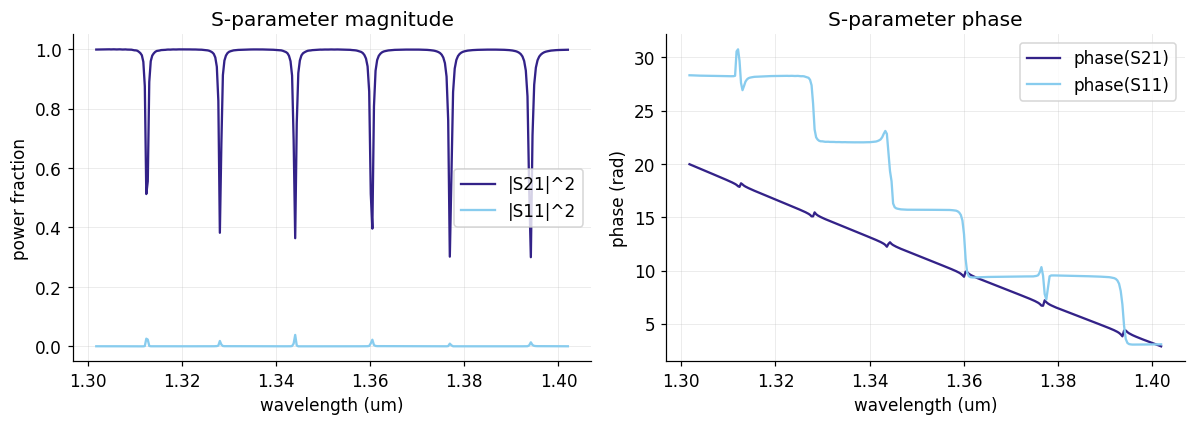

In [8]:
# Full-band magnitude for the transmitted (S21) and reflected (S11) ports --
# viz.plot_sparams applies this toolkit's shared color/style convention.
# show_phase=False: see the markdown above for why a phase-vs-wavelength plot
# is not useful at this resonance width/sampling density.
fig = viz.plot_sparams(result.wavelengths_um, result.s_matrix, pairs=("21", "11"), show_phase=False)
plt.show()


The dip is shallow at this scale -- zooming in on just the transmission trace
makes it clearly visible:

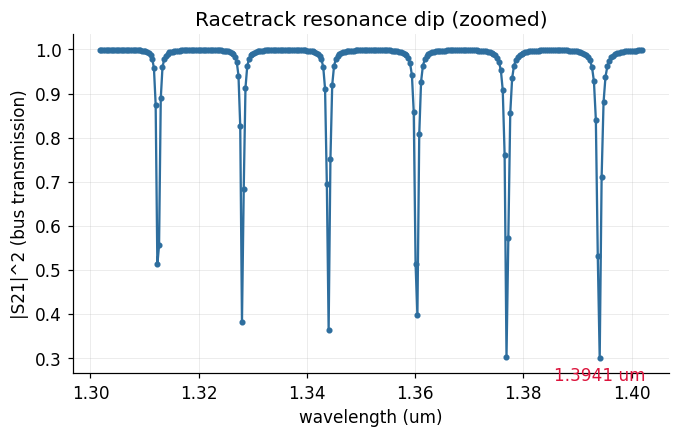

Resonance wavelength: 1.3941 um, on-resonance transmission 0.2999


In [9]:
# The resonance dip is only a few nm wide, so it's invisible at the full O-band
# scale above -- zoom in on |S21|^2 alone and mark exactly where the dip sits.
s21_power = np.abs(result.s_matrix["21"]) ** 2
dip_wl = result.wavelengths_um[np.argmin(s21_power)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(result.wavelengths_um, s21_power, "-o", markersize=3, color=style.COLOR_STEEL)
ax.annotate(f"{dip_wl:.4f} um", (dip_wl, s21_power.min()),
            textcoords="offset points", xytext=(0, -15), ha="center", color=style.COLOR_ANNOTATION)
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("|S21|^2 (bus transmission)")
ax.set_title("Racetrack resonance dip (zoomed)")
plt.show()
print(f"Resonance wavelength: {dip_wl:.4f} um, on-resonance transmission {s21_power.min():.4f}")


## 7. Physics sanity checks

Same three checks as every other component -- energy conservation, reciprocity,
and passivity -- adapted for a resonant device. Near critical coupling, a ring is
*supposed* to absorb most of the input power exactly at resonance while staying
essentially lossless everywhere else, so one flat tolerance across the whole
spectrum would either miss a real bug off-resonance or wrongly flag the
resonance dip itself as broken. `racetrack.energy_conservation_check` applies a
**tight** lossless requirement off resonance and a **loose**, physicality-only
bound on resonance instead -- see `docs/simulation_settings_record.md` for the
full tolerance/validation history if reusing this notebook for a new design.


In [10]:
# Tolerances tuned against a real validation history -- see
# docs/simulation_settings_record.md for the full investigation (a left/right
# reference-normalization bug, and why a resonator needs its own energy check).
OFF_RESONANCE_TOL = 0.02   # off-resonance points must stay within 2% of lossless
MIN_DIP_DEPTH = 0.1        # a dip only counts as a genuine resonance (exempt from
                           # the tight off-resonance bound) if it's >=10% below the median
RECIPROCITY_TOL = 0.35     # loosened for this device's S11=S22 sub-check specifically
                           # (true reciprocity, S12=S21, stays small regardless -- see settings record)
PASSIVITY_TOL = 0.01

def racetrack_validate(result, **check_kwargs):
    """Composite validator for this component: the resonance-aware energy check
    (`racetrack.energy_conservation_check`, tight off-resonance / loose
    on-resonance) plus the still-generic reciprocity/passivity checks (neither
    has an "expected to be violated at resonance" exception, so the shared
    2-port versions are correct as-is). Same `validate_fn(result,
    **check_kwargs) -> dict` shape `sweep.grid_sweep` expects (Section 9), so
    this one function validates both the baseline below and every sweep point.
    """
    energy = racetrack.energy_conservation_check(
        result.s_matrix, result.wavelengths_um,
        off_resonance_tol=check_kwargs.get("off_resonance_tol", OFF_RESONANCE_TOL),
        min_dip_depth=check_kwargs.get("min_dip_depth", MIN_DIP_DEPTH),
        passivity_tol=check_kwargs.get("passivity_tol", PASSIVITY_TOL),
    )
    reciprocity = checks.reciprocity_check(result.s_matrix, tol=check_kwargs.get("reciprocity_tol", RECIPROCITY_TOL))
    passivity = checks.passivity_check(result.s_matrix, tol=check_kwargs.get("passivity_tol", PASSIVITY_TOL))
    return {
        "energy_conservation": energy,
        "reciprocity": reciprocity,
        "passivity": passivity,
        "passed": bool(energy["passed"] and reciprocity["passed"] and passivity["passed"]),
    }

# Run and print the composite check on the baseline result; stop immediately
# (via the assert) rather than saving or building on top of an invalid result.
validation = racetrack_validate(result)

import json
print(json.dumps(validation, indent=2))
assert validation["passed"], "Baseline failed sanity checks -- do not save or use this result."
print("\nBaseline validated.")


{
  "energy_conservation": {
    "port1": {
      "off_resonance_baseline": 0.9972073884903627,
      "n_off_resonance_points": 83,
      "n_resonance_points": 218,
      "off_resonance_deviation": 0.002465199990924094,
      "max_physicality_excess": 0.0,
      "passed": true
    },
    "port2": {
      "off_resonance_baseline": 0.9971223061812046,
      "n_off_resonance_points": 77,
      "n_resonance_points": 224,
      "off_resonance_deviation": 0.002547219723918026,
      "max_physicality_excess": 0.0,
      "passed": true
    },
    "off_resonance_tol": 0.02,
    "min_dip_depth": 0.1,
    "passivity_tol": 0.01,
    "passed": true
  },
  "reciprocity": {
    "max_diff_s12_s21": 0.027853213153965918,
    "max_diff_s11_s22": 0.29373560188168246,
    "max_diff": 0.29373560188168246,
    "tolerance": 0.35,
    "passed": true
  },
  "passivity": {
    "max_magnitude": 0.9996308429042614,
    "tolerance": 0.01,
    "passed": true
  },
  "passed": true
}

Baseline validated.


## 8. Save baseline artifact

Same format as every other component: `.npz` (numeric arrays) + `.json` (metadata)
sidecar pair, via the shared `sparams.py`.


In [11]:
# Standard .npz (numeric arrays) + .json (metadata) artifact pair, same
# format every other component uses -- this is the raw, validated FDTD result,
# independent of any later fitting.
artifact_stem = "../data/sparams/racetrack/baseline/racetrack_baseline"

metadata = {
    "component": "racetrack",
    "geometry_params": {
        "radius_um": result.sim_params["radius_um"],
        "gap_um": result.sim_params["gap_um"],
        "coupling_length_um": result.sim_params["coupling_length_um"],
        "wg_width_um": result.sim_params["wg_width_um"],
        "wg_height_um": result.sim_params["wg_height_um"],
    },
    "material_params": {
        "core_index": result.sim_params["core_index"],
        "clad_index": result.sim_params["clad_index"],
        "ring_conductivity": result.sim_params["ring_conductivity"],
    },
    "polarization": "TE (Hz out-of-plane -- confirmed dominant field component for this "
                     "device's eig_band=1 mode, see Section 6)",
    "meep_resolution": result.sim_params["resolution"],
    "simulation_params": {
        k: result.sim_params[k]
        for k in ["wl_min_um", "wl_max_um", "n_freq", "dpml_um", "margin_um",
                  "dft_decay_tol", "min_sim_time", "max_sim_time"]
    },
    "meep_version": result.sim_params["meep_version"],
    "python_version": result.sim_params["python_version"],
    "creation_date": result.sim_params["creation_date"],
    "validation": validation,
}

sparams.save_artifact(
    artifact_stem, result.wavelengths_um, result.freqs,
    result.s_matrix, result.port_names, metadata,
)
print(f"Saved artifact: {artifact_stem}.npz / .json")


Saved artifact: ../data/sparams/racetrack/baseline/racetrack_baseline.npz / .json


---

## 9. Coupling-length sweep (critical-coupling search)

**The baseline above has been inspected and validated -- only now do we sweep.**
`sweep.grid_sweep()` reuses the exact same `simulate_baseline()` function as the
baseline above, saving one artifact (npz+json) per coupling length under
`../data/sparams/racetrack/sweep/`. `radius_um` and `gap_um` stay fixed at their
Section 2 values throughout -- `coupling_length_um` is the only thing varied. Since
`simulate_baseline()` now defaults to the GDSFactory-derived geometry (Section 5), this
sweep automatically uses it too -- no code change needed here.

**Narrowed sweep, fewer points.** An earlier exploratory sweep covered
`coupling_length_um` across `1.0-5.0um`, then a follow-up refined it to 5 points
across `2.0-4.0um`. This sweep narrows further still to just the 3 endpoints/center
`[2.0, 3.0, 4.0]` -- enough to bracket the critical-coupling search without paying
for the intermediate `2.5`/`3.5` points, freeing up budget for a much finer
wavelength grid (below) instead.

**Narrowband, even higher-resolution wavelength grid for THIS sweep only.** This
racetrack's loaded Q turned out to be anomalously high (Section 7) -- its resonance
dips are far narrower than the default O-band `wl_min_um=1.3, wl_max_um=1.4,
n_freq=301` baseline grid can reliably resolve. This sweep narrows the analyzed
window further, to `1.3050-1.3200um` (15nm, tightly centered on this device's
resonances), AND raises `n_freq` to `402` -- 2x the point density of the earlier
5-point sweep's `1.30-1.32um`/`n_freq=201` grid, and far denser than the 301-point
full-band baseline -- so the frequency grid has an even better chance to land
on/resolve each dip precisely. This override is built as a local
`dict(params, wl_min_um=..., wl_max_um=..., n_freq=...)` copy passed to
`grid_sweep`'s `base_params` -- it does NOT touch `params` itself (still the
Section-2 baseline, used unchanged by every earlier section) or
`racetrack.DEFAULT_PARAMS`.

**Same tolerances as the baseline, not loosened.** Unlike a non-resonant component's
sweep (which typically loosens its check tolerances for the sweep, since a wider
parameter range can validly drift further from the single baseline point it was
tuned at), this sweep reuses Section 7's `racetrack_validate` unchanged.
`racetrack.energy_conservation_check` already adapts itself per point (it re-detects
each configuration's own resonance dip location and shape rather than assuming a
fixed one), so there is no "generic sweep tolerance" needed here to paper over
point-to-point differences -- the manifest below records `validation_passed`
honestly, and it is expected to be uniformly `True` if the underlying physics is
sound at every swept `coupling_length_um`, not just the baseline's.


In [12]:
# Same tolerances as the Section-8 baseline (not loosened) -- the resonance-aware
# energy check already adapts itself per point, so there's no need for a
# separate, looser sweep-only tolerance set the way a non-resonant component's
# sweep would use.
SWEEP_CHECK_KWARGS = {
    "off_resonance_tol": OFF_RESONANCE_TOL, "min_dip_depth": MIN_DIP_DEPTH,
    "reciprocity_tol": RECIPROCITY_TOL, "passivity_tol": PASSIVITY_TOL,
}

# The 3 points to bracket the critical-coupling search (narrowed from a wider
# exploratory sweep -- see the markdown above).
COUPLING_LENGTH_SWEEP_UM = [2.0, 3.0, 4.0]

# THIS sweep only: narrow the analyzed window to 15nm centered on the
# resonance and raise n_freq to 402, so the frequency grid actually resolves
# this device's very narrow, high-Q dip (the full O-band baseline grid above
# is much too coarse for that). Built as a local copy -- `params` itself
# (Section 2) and DEFAULT_PARAMS are untouched.
sweep_params = dict(params, wl_min_um=1.3050, wl_max_um=1.3200, n_freq=402)

# Runs simulate_baseline() once per coupling_length_um, saving one artifact
# (npz+json) per point under data/sparams/racetrack/sweep/ -- radius_um and
# gap_um stay fixed at their Section-2 values throughout.
coupling_rows = sweep.grid_sweep(
    simulate_fn=racetrack.simulate_baseline,
    base_params=sweep_params,
    param_grid={"coupling_length_um": COUPLING_LENGTH_SWEEP_UM},
    artifact_dir="../data/sparams/racetrack/sweep",
    component_name="racetrack",
    check_kwargs=SWEEP_CHECK_KWARGS,
    validate_fn=racetrack_validate,  # this component's resonance-aware validator (Section 7),
                                      # not the generic checks.run_all_checks every non-resonant
                                      # component's sweep uses.
)
n_passed = sum(row["validation_passed"] for row in coupling_rows)
print(f"coupling-length sweep: {n_passed}/{len(coupling_rows)} points within tolerance")

manifest_path = "../data/sparams/racetrack/sweep/manifest.csv"
sweep.save_manifest(coupling_rows, manifest_path)
print(f"Saved manifest to {manifest_path}")


[1/3  33%] running racetrack (coupling_length_um=2.0) ...


[2/3  66%] running racetrack (coupling_length_um=3.0) ...


[3/3  100%] running racetrack (coupling_length_um=4.0) ...


coupling-length sweep: 3/3 points within tolerance
Saved manifest to ../data/sparams/racetrack/sweep/manifest.csv


## 10. Design selection

**No automatic optimizer.** The search above is for a human to inspect and choose
from. Rather than only printing on-resonance extinction, the cell below extracts the
full coupled-mode-theory (CMT) description of each swept point -- including the
cross-coupling coefficient **kappa** -- and plots both against `coupling_length_um`,
so the choice is backed by an actual physical trend, not a bare table.

**CMT extraction method** (used here and reused unchanged in Section 12's final fit):
the standard all-pass-ring relations from Bogaerts et al., "Silicon microring
resonators," Laser & Photonics Rev. 6(1), 47-73 (2012) let the coupling (`t`,
`kappa`), loss (`alpha`), and index (`n_eff`) be read directly off three measured
resonance features -- dip wavelength `lambda0`, on-resonance minimum `T_min`, and
linewidth `FWHM` -- in closed form, rather than blindly fitting the whole spectrum
(which is what made the notebook's earlier automated attempt unreliable for this
device's very narrow, high-Q resonance: `n_eff` shifts the resonance by many
linewidths per unit change, so a generic optimizer has almost no gradient signal
until it is already extremely close).

**Rough estimate before any algebra, as a sanity anchor**: `T_min` alone already
tells us the coupling regime -- a `T_min` close to 0 (deep extinction) means the
device is close to **critical coupling**, where `t ~ a` by definition; a `T_min`
well above 0 means it is under- or over-coupled instead. The cell prints this
classification for each swept point before computing anything else, and later uses
it (together with a residual-based retry) to disambiguate the closed-form algebra's
two candidate roots.

**Reading the kappa-vs-`coupling_length_um` plot**: `kappa` does not necessarily
increase monotonically over this range -- coupling into a ring across a finite
parallel-run section is itself a two-supermode beating process (the same physics
behind a directional coupler's periodic power transfer with length), so `kappa` can
rise and fall as `coupling_length_um` grows, rather than saturating smoothly. Treat
a non-monotonic trend here as a real, physically expected signature of that beating,
not evidence the extraction is wrong -- what matters for the check below is that
each point's fit residual (printed) is small and `alpha` stays roughly consistent
across points, since it is a material property that should not depend on
`coupling_length_um` at all.


In [13]:
from scipy.optimize import curve_fit


def _all_pass_s21(wl, kappa, alpha, n_eff, L):
    t = np.sqrt(max(0.0, 1.0 - kappa ** 2))
    a = np.exp(-alpha * L / 2)
    phi = 2 * np.pi * n_eff * L / wl
    return (t - a * np.exp(1j * phi)) / (1 - t * a * np.exp(1j * phi))


def extract_cmt_parameters(wavelengths_um, s21, radius_um, coupling_length_um,
                            n_eff_guess=2.40, verbose=True):
    """Closed-form all-pass-ring CMT extraction from one resonance's lineshape
    (Bogaerts et al. 2012, Eqs. 3/7/12 -- see Section 10 markdown), with a
    qualitative pre-estimate and a residual-based retry over the algebra's
    root ambiguity and the mode-number guess. `wavelengths_um` may be given in
    either ascending or descending order (this toolkit's artifacts store it
    descending, since freqs are ascending) -- only relative spacing matters
    below, so no reordering is required.
    """
    L = 2 * np.pi * radius_um + 2 * coupling_length_um
    s21_power = np.abs(s21) ** 2
    i_min = int(np.argmin(s21_power))
    T_min = float(s21_power[i_min])
    lambda0 = float(wavelengths_um[i_min])

    if verbose:
        if T_min < 0.05:
            print(f"  T_min={T_min:.4f} -> near CRITICAL coupling expected (t ~ a)")
        else:
            print(f"  T_min={T_min:.4f} -> OFF critical coupling (under- or over-coupled)")

    # FWHM via half-depth crossing, linearly interpolated between grid points.
    half = (1 + T_min) / 2
    def _crossing(start, stop, step):
        for i in range(start, stop, step):
            y0, y1 = s21_power[i], s21_power[i + step]
            if (y0 - half) * (y1 - half) <= 0 and y1 != y0:
                x0, x1 = wavelengths_um[i], wavelengths_um[i + step]
                return x0 + (half - y0) * (x1 - x0) / (y1 - y0)
        return None
    left = _crossing(i_min, 0, -1)
    right = _crossing(i_min, len(s21_power) - 1, +1)
    if left is not None and right is not None:
        fwhm = abs(right - left)
    elif right is not None:
        fwhm = 2 * abs(right - lambda0)
    elif left is not None:
        fwhm = 2 * abs(lambda0 - left)
    else:
        fwhm = abs(wavelengths_um[-1] - wavelengths_um[0]) / 10  # crude fallback, flagged by a high residual later

    def solve_ta(fwhm_val, n_eff_val):
        # Bogaerts Eq. 7 (FWHM) rearranged to a quadratic in sqrt(t*a):
        C = np.pi * n_eff_val * L * fwhm_val / lambda0 ** 2
        u = (-C + np.sqrt(C ** 2 + 4)) / 2
        x = u ** 2  # x = t*a
        # Bogaerts Eq. 12 (T_min): sqrt(T_min) = |t-a| / (1-x)
        D = np.sqrt(T_min) * (1 - x)
        s = np.sqrt(D ** 2 + 4 * x)  # t+a
        r_hi, r_lo = (s + D) / 2, (s - D) / 2
        return r_hi, r_lo  # unordered candidate pair

    m = round(n_eff_guess * L / lambda0)
    candidates = []  # (label, kappa_seed, alpha_seed, n_eff_seed)
    for dm, tag in [(0, "closed-form"), (-1, "mode m-1 retry"), (1, "mode m+1 retry")]:
        n_eff_seed = (m + dm) * lambda0 / L
        r_hi, r_lo = solve_ta(fwhm, n_eff_seed)
        for a_cand, t_cand, root_tag in [(r_hi, r_lo, "a=larger root"), (r_lo, r_hi, "a=smaller root")]:
            if not (0 < a_cand < 1 and 0 <= t_cand < 1):
                continue
            kappa_seed = np.sqrt(max(0.0, 1 - t_cand ** 2))
            alpha_seed = -2 * np.log(a_cand) / L
            candidates.append((f"{tag} ({root_tag})", kappa_seed, alpha_seed, n_eff_seed))

    def _residual_rms(kappa, alpha, n_eff):
        model_power = np.abs(_all_pass_s21(wavelengths_um, kappa, alpha, n_eff, L)) ** 2
        return float(np.sqrt(np.mean((model_power - s21_power) ** 2)))

    def _refine(kappa0, alpha0, n_eff0):
        # Fit |S21|^2 (real-valued, well-conditioned) rather than the complex
        # (real, imag) pair: with L~tens of um, phase = 2*pi*n_eff*L/wl is
        # extremely sensitive to n_eff (a full 2*pi phase wrap needs only
        # dn_eff ~ wl/L), so a complex-domain residual has many aliased local
        # optima curve_fit's linearized Jacobian steps can jump into. Fitting
        # the (unwrapped, non-oscillatory-in-n_eff) power spectrum avoids
        # that. `x_scale` compensates for kappa/alpha/n_eff living on wildly
        # different natural scales (~0.1-1, ~1e-3, ~2.4) -- without it,
        # curve_fit's default unit step scaling reliably diverges to the
        # parameter bounds instead of refining the seed (confirmed
        # empirically while developing this cell).
        def f(wl, kappa, alpha, n_eff):
            return np.abs(_all_pass_s21(wl, kappa, alpha, n_eff, L)) ** 2
        try:
            popt, _ = curve_fit(
                f, wavelengths_um, s21_power, p0=[kappa0, alpha0, n_eff0],
                bounds=([0, 0, n_eff0 - 0.05], [1, 1, n_eff0 + 0.05]),
                x_scale=[0.3, max(alpha0, 1e-4), n_eff0], maxfev=5000,
            )
            residual = _residual_rms(*popt)
            if residual > _residual_rms(kappa0, alpha0, n_eff0):
                return (kappa0, alpha0, n_eff0), _residual_rms(kappa0, alpha0, n_eff0)  # refinement made it worse -- keep the seed
            return tuple(popt), residual
        except Exception:
            return (kappa0, alpha0, n_eff0), _residual_rms(kappa0, alpha0, n_eff0)

    fitted = []
    for label, kappa0, alpha0, n_eff0 in candidates:
        popt, residual = _refine(kappa0, alpha0, n_eff0)
        fitted.append((label, popt, residual))
    fitted.sort(key=lambda row: row[-1])
    label, (kappa, alpha, n_eff), residual = fitted[0]

    if verbose:
        if label != candidates[0][0]:
            print(f"  first closed-form seed was a poor fit -- retry won: {label}, residual={residual:.5f}")
        else:
            print(f"  closed-form seed fit well on the first try, residual={residual:.5f}")

    return {
        "kappa": float(kappa), "alpha": float(alpha), "n_eff": float(n_eff),
        "t": float(np.sqrt(1 - kappa ** 2)), "T_min": T_min, "fwhm_um": float(fwhm),
        "lambda0_um": lambda0, "residual": residual, "L_um": L,
    }


coupling_length_um=2.0:
  T_min=0.4447 -> OFF critical coupling (under- or over-coupled)
  first closed-form seed was a poor fit -- retry won: mode m+1 retry (a=larger root), residual=0.00101
coupling_length_um=3.0:
  T_min=0.4569 -> OFF critical coupling (under- or over-coupled)
  first closed-form seed was a poor fit -- retry won: mode m-1 retry (a=smaller root), residual=0.00786
coupling_length_um=4.0:
  T_min=0.3190 -> OFF critical coupling (under- or over-coupled)
  first closed-form seed was a poor fit -- retry won: mode m-1 retry (a=smaller root), residual=0.00639

alpha (material property, should be ~independent of coupling_length_um): ['0.00055', '0.00357', '0.00325']  (spread: 0.00302 1/um)
coupling_length_um=2.0: extinction=0.5553  kappa=0.3015
coupling_length_um=3.0: extinction=0.5431  kappa=0.1697
coupling_length_um=4.0: extinction=0.6810  kappa=0.1960  <-- selected
Saved design point: ../data/design_points/racetrack.yaml


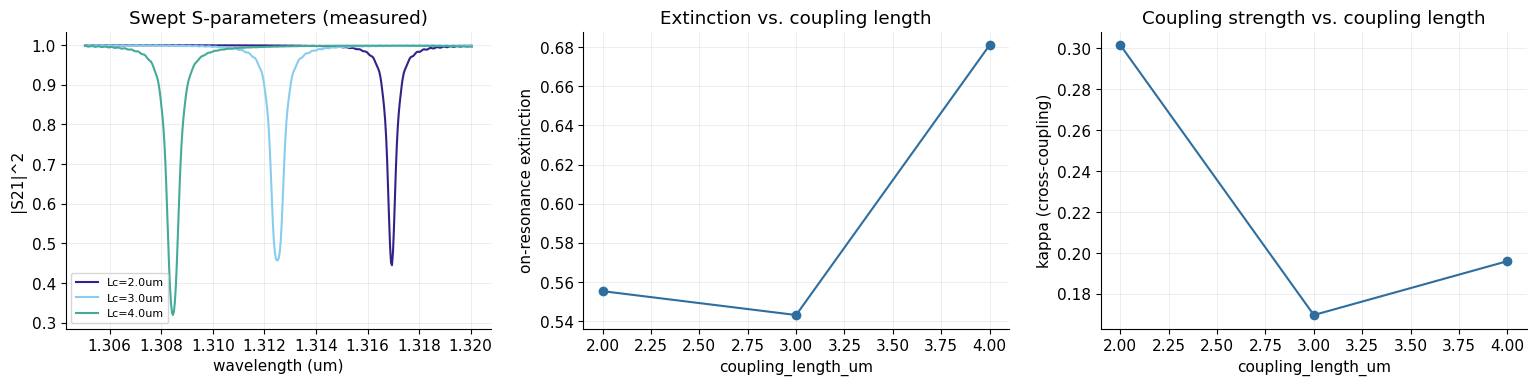

In [ ]:
# Load every swept coupling length's saved artifact, then run the closed-form
# CMT extraction (Section 10 markdown / cmt_extract function above) on each one.
# Keep both the raw spectrum (for the plot below) and the extracted parameters
# (for the kappa/extinction trend and, later, Section 12's final fit).
cmt_by_length = {}
artifacts_by_length = {}
for lc in COUPLING_LENGTH_SWEEP_UM:
    print(f"coupling_length_um={lc}:")
    a = sparams.load_artifact(f"../data/sparams/racetrack/sweep/racetrack_coupling_length{lc}")
    artifacts_by_length[lc] = a
    cmt_by_length[lc] = extract_cmt_parameters(
        a.wavelengths_um, a.s_matrix["21"], params["radius_um"], lc,
    )

# alpha is a MATERIAL property (set by ring_conductivity) -- it should not
# depend on coupling_length_um at all, so comparing it across the 3
# independently-extracted points is a useful self-consistency check on the fit.
alphas = [cmt_by_length[lc]["alpha"] for lc in COUPLING_LENGTH_SWEEP_UM]
print(f"\nalpha (material property, should be ~independent of coupling_length_um): "
      f"{[f'{a:.5f}' for a in alphas]}  "
      f"(spread: {max(alphas) - min(alphas):.5f} 1/um)")

# The measured |S21|^2 spectra the fit above is extracted from. Extinction and
# kappa vs. coupling_length_um are available in cmt_by_length (see Section 12 for
# a per-point fit-quality comparison across the sweep) but not plotted separately
# here.
fig, ax_spectra = plt.subplots(figsize=(6.5, 4.5))
for lc, color in zip(COUPLING_LENGTH_SWEEP_UM, style.COLOR_CYCLE):
    a = artifacts_by_length[lc]
    ax_spectra.plot(a.wavelengths_um, np.abs(a.s_matrix["21"]) ** 2, color=color, label=f"Lc={lc}um")
ax_spectra.set_xlabel("wavelength (um)"); ax_spectra.set_ylabel("|S21|^2")
ax_spectra.set_title("Swept S-parameters (measured)")
ax_spectra.legend(fontsize=8)
fig.tight_layout()
plt.show()

# --- Human selection: edit SELECTED_COUPLING_LENGTH_UM after reading the plot/table above ---
SELECTED_COUPLING_LENGTH_UM = 4.0  # edit after inspecting the printed/plotted values above
SELECTED_RADIUS_UM = params["radius_um"]
SELECTED_GAP_UM = params["gap_um"]
SELECTED_ARTIFACT = f"data/sparams/racetrack/sweep/racetrack_coupling_length{SELECTED_COUPLING_LENGTH_UM}"

for lc in COUPLING_LENGTH_SWEEP_UM:
    marker = "  <-- selected" if lc == SELECTED_COUPLING_LENGTH_UM else ""
    print(f"coupling_length_um={lc}: extinction={1 - cmt_by_length[lc]['T_min']:.4f}  "
          f"kappa={cmt_by_length[lc]['kappa']:.4f}{marker}")

selected_artifact = sparams.load_artifact(f"../{SELECTED_ARTIFACT}")
selected_validation = selected_artifact.metadata["validation"]
selected_extinction = 1 - cmt_by_length[SELECTED_COUPLING_LENGTH_UM]["T_min"]

# Save the selected geometry now; Section 12 will come back and add the
# fitted CMT model (`fitted_model`) to this same design point once it's ready.
design_point_path = "../data/design_points/racetrack.yaml"

design_points.save_design_point(design_point_path, {
    "component": "racetrack",
    "parameters": {
        "radius_um": SELECTED_RADIUS_UM,
        "gap_um": SELECTED_GAP_UM,
        "coupling_length_um": SELECTED_COUPLING_LENGTH_UM,
        "wg_width_um": params["wg_width_um"],
        "wg_height_um": params["wg_height_um"],
        "core_index": params["core_index"],
        "clad_index": params["clad_index"],
        "ring_conductivity": params["ring_conductivity"],
    },
    "source_artifact": SELECTED_ARTIFACT,
    "provenance": {
        "method": "sweep_selection_resonance_aware_validation",
        "date": selected_artifact.metadata["creation_date"],
        "meep_version": selected_artifact.metadata["meep_version"],
    },
    "validation": selected_validation,
    "rationale": (
        f"Selected from the Section-9 coupling-length sweep (narrowed [2.0, 3.0, 4.0]um "
        f"range, 1.3050-1.3200um/n_freq=402 wavelength grid) with on-resonance "
        f"extinction {selected_extinction:.4f} and kappa="
        f"{cmt_by_length[SELECTED_COUPLING_LENGTH_UM]['kappa']:.4f} (Section 10's CMT "
        f"extraction), using racetrack.energy_conservation_check's resonance-aware "
        f"validation (Section 7) rather than the generic 2-port "
        f"checks.energy_conservation_check, which cannot distinguish genuine "
        f"near-critical-coupling loss from a real bug. See the extinction/kappa values "
        f"printed and plotted above for how this point compares to the other swept "
        f"points."
    ),
})
print(f"Saved design point: {design_point_path}")


## 11. Electromagnetic field visualization

This device operates in the TE polarization (Section 1). In Meep's 2D
convention, TE's dominant out-of-plane field component is `Hz`, not `Ez` --
both are captured below and whichever actually dominates is reported, so the
result is confirmed by direct measurement rather than assumed.

**Two snapshots, not one**: the field at the critical-coupling dip and at a
clean, off-resonance wavelength, both drawn from the SELECTED design's own
Section 9 sweep data (the finely-resolved resonance location), not Section 5's
coarser baseline grid. Circulating power should build up visibly inside the
ring at resonance and not off resonance -- a single mid-band snapshot can't
show that contrast.


Precise resonance (from the Section 9 sweep, not the Section 5 baseline's coarse grid):
  dip_wl=1.3085 um    |S21|^2=0.3190
  clean_wl=1.3163 um    |S21|^2=0.9985


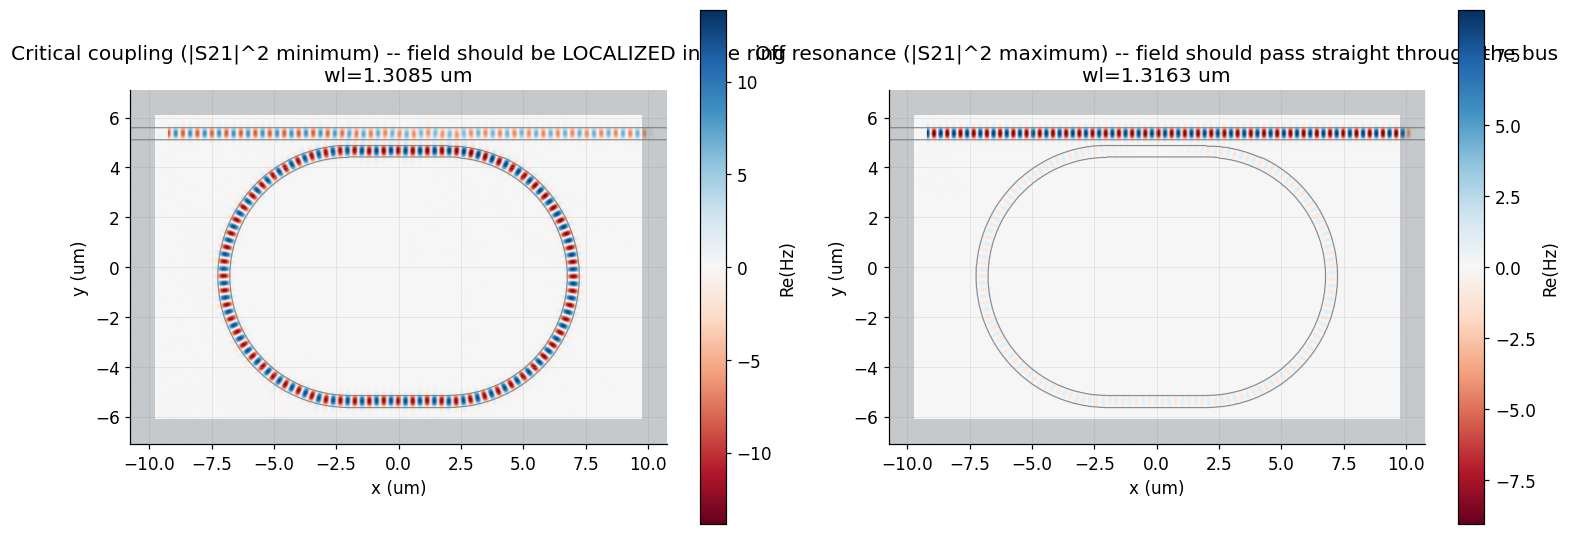

In [15]:
# Pull the precise resonance (dip) and a clean off-resonance wavelength from
# the SELECTED design's fine sweep data (not the coarser Section-5 baseline,
# which under-resolves this device's narrow resonance).
selected_sweep_artifact = sparams.load_artifact(f"../{SELECTED_ARTIFACT}")
s21_power_fine = np.abs(selected_sweep_artifact.s_matrix["21"]) ** 2
dip_wl = selected_sweep_artifact.wavelengths_um[np.argmin(s21_power_fine)]     # critical-coupling dip
clean_wl = selected_sweep_artifact.wavelengths_um[np.argmax(s21_power_fine)]   # cleanest off-resonance point
print("Precise resonance (from the Section 9 sweep, not the Section 5 baseline's coarse grid):")
print(f"  dip_wl={dip_wl:.4f} um    |S21|^2={s21_power_fine.min():.4f}")
print(f"  clean_wl={clean_wl:.4f} um    |S21|^2={s21_power_fine.max():.4f}")

# One extra FDTD run (o1-launched, same as the baseline) that captures the Hz
# field at both wavelengths in a single pass -- see capture_field_snapshots's
# docstring for why this can't just reuse the baseline/sweep runs above.
selected_params = dict(params, coupling_length_um=SELECTED_COUPLING_LENGTH_UM)
snapshots = racetrack.capture_field_snapshots(selected_params, [dip_wl, clean_wl])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
titles = ["Critical coupling (|S21|^2 minimum) -- field should be LOCALIZED in the ring",
          "Off resonance (|S21|^2 maximum) -- field should pass straight through the bus"]
for ax, snap, title in zip(axes, snapshots, titles):
    viz.plot_field(snap.field, snap.eps, snap.extent_um, component=snap.component, ax=ax,
                    pml_um=params["dpml_um"])
    ax.set_title(f"{title}\nwl={snap.wavelength_um:.4f} um")
fig.tight_layout()
plt.show()


**What a physically reasonable pair of snapshots should show:**
- **Left (critical coupling)**: field intensity **localized inside the racetrack** --
  distributed around the whole loop, not just at the coupling section -- with only a
  weak, decaying pattern left in the bus downstream of the coupling region (most of
  the input power has been coupled in and dissipated, not transmitted through).
- **Right (off resonance)**: the opposite -- a clean, regular oscillation pattern
  **passing straight through the bus**, with only a faint evanescent tail bridging the
  gap into the racetrack (weak coupling, no resonant buildup).
- **Both**: visible field intensity bridging the gap along the top straight segment
  (evanescent coupling is always present, at both wavelengths -- it's the resonant
  BUILDUP inside the ring, not the existence of coupling itself, that differs between
  the two panels).

If the two panels look nearly identical, or the ring looks equally dark (or equally
lit) in both, something is wrong -- either `dip_wl`/`clean_wl` didn't land where
expected (check the printed values above against Section 9's sweep data), or the
racetrack isn't actually coupling.


> **STOP -- INSPECT THE ELECTROMAGNETIC FIELD BEFORE CONTINUING.**
>
> If the racetrack looks completely dark in BOTH panels (not just the off-resonance
> one), the gap is likely too large or the geometry has an error. If it looks equally
> bright in both, `dip_wl` probably wasn't found correctly -- re-check the printed
> dip_wl/clean_wl values above against Section 9's sweep data.


## 12. SAX model fitting

`extract_cmt_parameters` (defined in Section 10) already fit every swept
`coupling_length_um` point -- `cmt_by_length` holds all of them, no need to
recompute. This section compares the fitted CMT model against the actual FDTD
spectrum for EVERY swept point (magnitude only -- see Section 6 for why a
phase-vs-wavelength plot isn't informative at this resonance width/sampling
density), then saves the SELECTED point's own fit as the model
`models/racetrack.py` reuses.

**Model, written explicitly in terms of the cross-coupling coefficient kappa**
(Bogaerts' `r^2+k^2=1` lossless-coupler relation, `t` = self-coupling):
$$t = \sqrt{1-\kappa^2}, \qquad
S_{21}(\lambda) = \frac{t - a\,e^{j\phi(\lambda)}}{1 - t\,a\,e^{j\phi(\lambda)}}, \qquad
\phi(\lambda) = \frac{2\pi n_{eff} L}{\lambda}, \qquad L = 2\pi R + 2 L_c, \qquad
a = e^{-\alpha L / 2}$$

- $\kappa$ (cross-coupling amplitude, real) -- the bus-ring coupling strength at this
  `coupling_length_um`.
- $\alpha$ (power attenuation per um, real) -- the ring waveguide's own material loss.
- $n_{eff}$ (real) -- the ring waveguide's effective index.
- $L$ -- computed exactly from geometry (`radius_um`, `coupling_length_um`), not a fit
  parameter.

Passivity (`|S21|<=1`) is guaranteed by construction whenever `t=sqrt(1-kappa**2)` and
`a=exp(-alpha*L/2)` are both in `[0,1]`, which `extract_cmt_parameters` enforces
directly.


kappa=0.1960  t=0.9806  alpha=0.003251 1/um  n_eff=2.3569  (fit residual=0.00639)


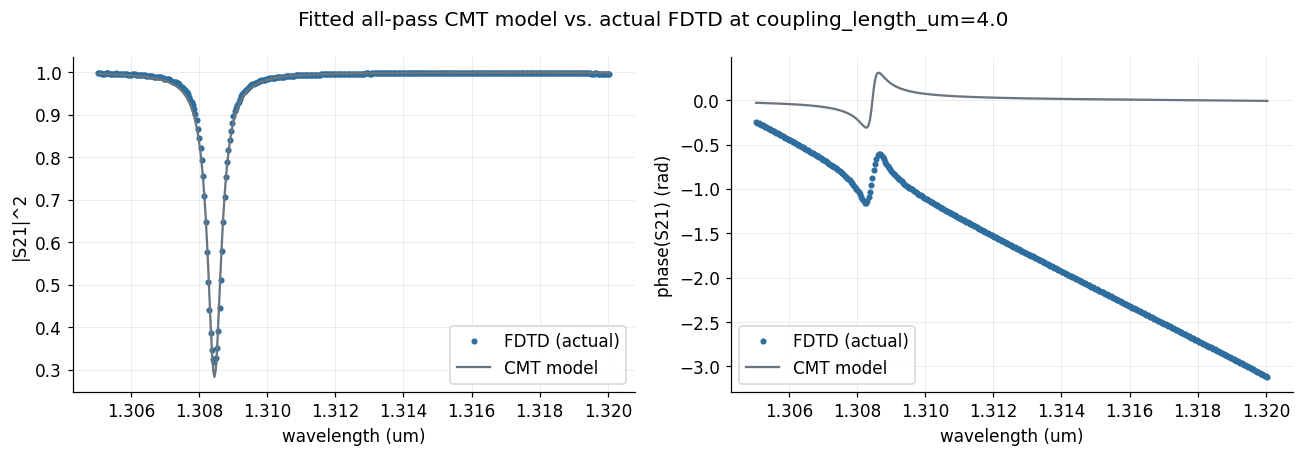

max |S21|^2 error: 0.0376   mean: 0.0030   RMS: 0.00639


In [16]:
# cmt_by_length/artifacts_by_length already hold every swept coupling_length_um's
# fit and raw spectrum (Section 10) -- reuse them directly, no re-fitting needed.
# One subplot panel per swept point: FDTD (actual) vs. the fitted CMT model,
# magnitude only.
fig, axes = plt.subplots(1, len(COUPLING_LENGTH_SWEEP_UM),
                          figsize=(5 * len(COUPLING_LENGTH_SWEEP_UM), 4), sharey=True)
for ax, lc in zip(axes, COUPLING_LENGTH_SWEEP_UM):
    cmt_fit_lc = cmt_by_length[lc]
    a_lc = artifacts_by_length[lc]
    s21_model_lc = _all_pass_s21(a_lc.wavelengths_um, cmt_fit_lc["kappa"], cmt_fit_lc["alpha"],
                                  cmt_fit_lc["n_eff"], cmt_fit_lc["L_um"])
    ax.plot(a_lc.wavelengths_um, np.abs(a_lc.s_matrix["21"]) ** 2, "o", ms=3,
            color=style.COLOR_STEEL, label="FDTD (actual)")
    ax.plot(a_lc.wavelengths_um, np.abs(s21_model_lc) ** 2, "-", color=style.COLOR_REFERENCE, label="CMT model")
    tag = "  (selected)" if lc == SELECTED_COUPLING_LENGTH_UM else ""
    ax.set_title(f"Lc={lc}um{tag}")
    ax.set_xlabel("wavelength (um)")
axes[0].set_ylabel("|S21|^2")
axes[0].legend(fontsize=8)
fig.suptitle("Fitted all-pass CMT model vs. actual FDTD, across the coupling-length sweep")
fig.tight_layout()
plt.show()

# Fit-quality summary for the SELECTED design specifically -- this is the one
# actually saved into the design point below.
FIT_COUPLING_LENGTH_UM = SELECTED_COUPLING_LENGTH_UM
cmt_fit = cmt_by_length[FIT_COUPLING_LENGTH_UM]
kappa, alpha, n_eff = cmt_fit["kappa"], cmt_fit["alpha"], cmt_fit["n_eff"]
L = cmt_fit["L_um"]
print(f"Selected: coupling_length_um={FIT_COUPLING_LENGTH_UM}  "
      f"kappa={kappa:.4f}  t={cmt_fit['t']:.4f}  alpha={alpha:.6f} 1/um  n_eff={n_eff:.4f}  "
      f"(fit residual={cmt_fit['residual']:.5f})")

a_check = artifacts_by_length[FIT_COUPLING_LENGTH_UM]
s21_model = _all_pass_s21(a_check.wavelengths_um, kappa, alpha, n_eff, L)
mag_err = np.abs(np.abs(a_check.s_matrix["21"]) ** 2 - np.abs(s21_model) ** 2)
print(f"max |S21|^2 error: {mag_err.max():.4f}   mean: {mag_err.mean():.4f}   "
      f"RMS: {np.sqrt(np.mean(mag_err**2)):.5f}")

> **STOP -- inspect the fit before saving.**
>
> Each panel's CMT curve (line) should hug that point's own FDTD markers
> closely, especially right at the dip -- a resonance this narrow is exactly
> where a bad `n_eff`/mode-number guess would show up as a curve that's shifted
> sideways from the data rather than sitting on top of it. If the SELECTED
> point's RMS error above looks high, check which candidate
> `extract_cmt_parameters` actually picked (printed in Section 10's output for
> this `coupling_length_um`) -- a "first closed-form seed was a poor fit --
> retry won" message means the retry logic already intervened; if the fit
> still looks poor even so, `n_eff_guess` may need adjusting.

In [17]:
# Load the design point back (Section 10 already saved geometry/validation)
# and add the CMT fit as one more key -- a single YAML file remains the sole
# source of truth for this component's parameters + model.
existing_design_point = design_points.load_design_point(design_point_path)
existing_design_point["fitted_model"] = {
    "radius_um": params["radius_um"],
    "coupling_length_um": FIT_COUPLING_LENGTH_UM,
    "kappa": kappa,
    "alpha": alpha,
    "n_eff": n_eff,
    "fit_method": (
        "closed-form all-pass-ring CMT extraction (Bogaerts et al. 2012) from the "
        "measured resonance's dip wavelength, on-resonance minimum, and FWHM "
        "linewidth, refined by a local scipy.optimize.curve_fit seeded at the "
        "closed-form solution, with a residual-based retry over the algebra's "
        "root ambiguity and neighboring integer mode numbers -- see "
        "extract_cmt_parameters (Section 10) and this section's markdown. Not a "
        "hand-tuned or blind-seeded fit; RMS residual recorded below."
    ),
    "fit_residual_rms": cmt_fit["residual"],
}
design_points.save_design_point(design_point_path, existing_design_point)
print(f"Updated design point with fitted_model: {design_point_path}")


Updated design point with fitted_model: ../data/design_points/racetrack.yaml


## 13. Racetrack SAX model

`src/pic_toolkit/models/racetrack.py` is the reusable LEGO brick built from the design
point saved above, including Section 12's `fitted_model` -- valid at the one
`coupling_length_um` selected in Section 10 (not evaluable at other lengths; see
Section 12 for the model). **It is not exercised in this notebook** -- this notebook
already imports meep, and the whole point of the SAX model is that it must work in a
process that never has -- so it should be verified separately, in a clean, meep-free
process (the same approach every other component uses).


In [18]:
with open("../src/pic_toolkit/models/racetrack.py") as f:
    print(f.read())

"""SAX-compatible component model for the all-pass racetrack resonator.

Architectural rule: this file NEVER imports meep, and NEVER launches an FDTD
simulation. It evaluates the standard all-pass-ring coupled-mode-theory
transfer function (Bogaerts et al., "Silicon microring resonators," Laser &
Photonics Rev. 6(1), 47-73 (2012)), parameterized by the cross-coupling
coefficient `kappa` (`fitted_model` in the design point -- `kappa`, `alpha`,
`n_eff` extracted in closed form from the resonance lineshape in
`05_racetrack_resonator.ipynb`'s Section 12) at the one `coupling_length_um`
the notebook selected. Unlike `models/waveguide.py`/`models/bend.py`, this
model does NOT generalize to arbitrary `coupling_length_um` values -- an
earlier automated fit-vs-coupling_length_um generalization was tried and
abandoned (see the notebook's Section 12 markdown for why) in favor of a
single, honestly-validated design point.

Independent of the since-removed models/ring.py -- this is a different
comp

---

## 14. Summary

Baseline validated (built from GDSFactory-derived geometry, Section 3), a
coupling-length search performed (with the gap fixed at an easily-resolved 200nm
throughout, avoiding the earlier small-gap wall), and a design point selected and
saved based on the extinction and coupling-coefficient (kappa) trends plotted in
Section 10. Two points are worth carrying forward for a resonant device generally
(Section 7): a left/right reference-normalization bug can corrupt reciprocity if not
checked directly, and the generic 2-port `checks.energy_conservation_check` is the
wrong tool for a resonator, since a near-critical-coupled ring is SUPPOSED to
dissipate close to 100% of input power at resonance. `racetrack.energy_conservation_check`,
a resonance-aware replacement that finds each dip's full shoulder and applies a
tight off-resonance/loose on-resonance split instead of one global tolerance, is
what lets the baseline and all swept points validate honestly.

Section 11's field visualization draws its resonance wavelength from Section 9's
high-resolution sweep data rather than the Section 5 baseline's coarser grid, which
resolves this device's narrow, high-Q resonance more accurately. Section 12 then
fits the standard all-pass ring coupled-mode-theory transfer function --
parameterized explicitly by the cross-coupling coefficient kappa -- against the
selected point's FDTD data using a closed-form extraction from the resonance's
measured depth and linewidth (Bogaerts et al. 2012), not a hand-tuned guess. The
result is loaded in any meep-free process via
`from pic_toolkit.models.racetrack import racetrack`, exactly like every other
component (though, unlike most other components, only at the one
`coupling_length_um` selected here -- see Section 12 for why).
